In [1]:
import numpy as np
import matplotlib.pyplot as plt
import phobos
arch = phobos.Arch6()
phobos.XPOW().turn_off()
phobos.FilterWheel().move(6)

✅ BMC lib found. Running in control mode.
Filter Wheel connected on port /dev/ttyUSBthorlabs
FILT - Move to position 6


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:   0%|          | 0/4 [00:00<?, ?it/s]

Turned off injection segments: [138, 137, 136, 135]
Cred3 camera initialized with dark subtraction


Calibrating injection:  25%|██▌       | 1/4 [00:12<00:37, 12.35s/it]

[calibrate_injection] seg=138: centroid->(tip,tilt)=(-0.344,1.902) mrad; snapped=(-0.400,2.000); flux_max=3.91e+03
Turned off injection segments: [138, 137, 136, 135]


...

[calibrate_injection] seg=137: centroid->(tip,tilt)=(0.089,1.803) mrad; snapped=(0.000,1.800); flux_max=4.56e+03
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  75%|███████▌  | 3/4 [00:36<00:12, 12.25s/it]

[calibrate_injection] seg=136: centroid->(tip,tilt)=(0.387,1.608) mrad; snapped=(0.400,1.600); flux_max=3.39e+03
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection: 100%|██████████| 4/4 [00:48<00:00, 12.22s/it]

[calibrate_injection] seg=135: centroid->(tip,tilt)=(0.527,1.600) mrad; snapped=(0.600,1.600); flux_max=5.06e+03
[calibrate_injection] seg=138: balanced on ray to match ref_flux=3.39e+03 -> (tip,tilt)=(-0.396,1.981) mrad; flux_bal=3.39e+03
[calibrate_injection] seg=137: balanced on ray to match ref_flux=3.39e+03 -> (tip,tilt)=(0.000,1.724) mrad; flux_bal=3.39e+03
[calibrate_injection] seg=135: balanced on ray to match ref_flux=3.39e+03 -> (tip,tilt)=(0.367,0.978) mrad; flux_bal=3.39e+03


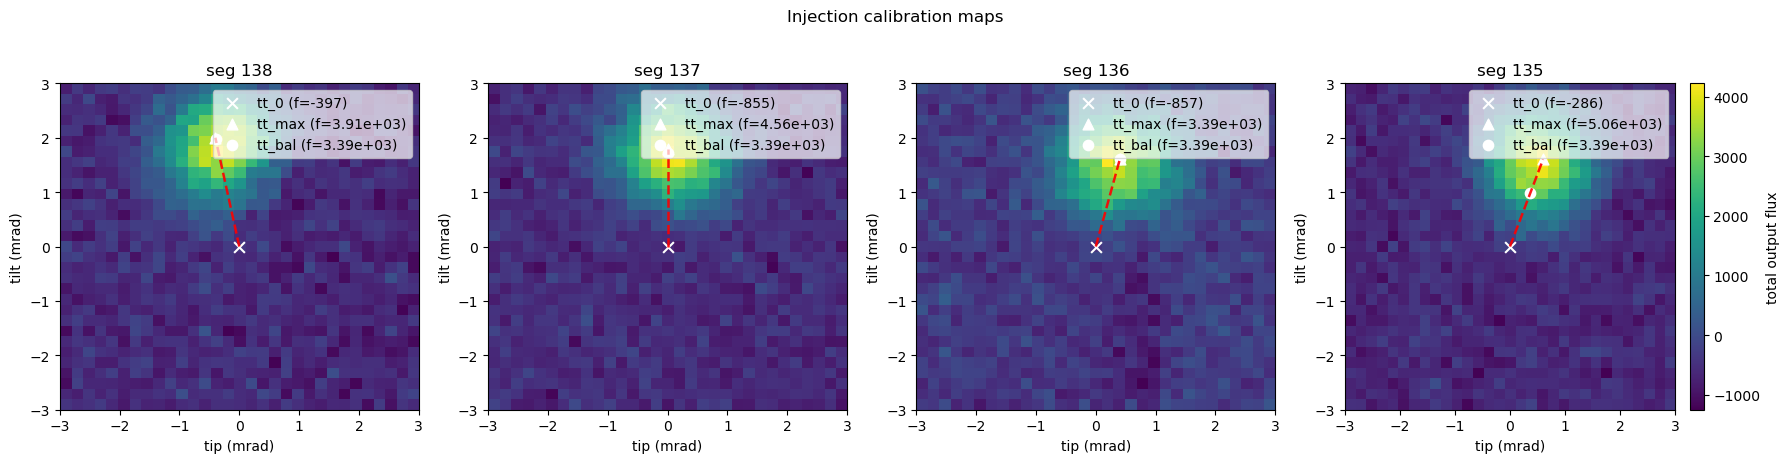

✅ Injection calibration saved to config under dm.ptt_max and dm.ptt_balanced


{'max': {'138': [-1150.0, -0.3999999999999999, 2.0],
  '137': [-1150.0, 0.0, 1.8000000000000007],
  '136': [-1150.0, 0.40000000000000036, 1.6000000000000005],
  '135': [-1150.0, 0.6000000000000001, 1.6000000000000005]},
 'balanced': {'138': [-1150.0, -0.39620430605628537, 1.9810215302814274],
  '137': [-1150.0, 0.0, 1.7237508013734286],
  '136': [-1150.0, 0.40000000000000036, 1.6000000000000005],
  '135': [-1150.0, 0.36686327183515816, 0.9783020582270886]},
 'figure': <Figure size 1800x450 with 5 Axes>}

In [2]:
phobos.DM().calibrate_injection(plot=True, verbose=True)

In [3]:
phobos.DM().balanced()
outs = arch.phase_calibration()
phobos.XPOW().turn_off()

Applied BALANCED injection calibration on segments: [138, 137, 136, 135]


---

# MMI Caracterization

In [ ]:
# Show phasors before solving matrix (use previous model)
raw_phasors = phobos.Arch6().predict_phasors(plot=True)

# Solve matrix
solved_matrix = arch.solve_matrix(plot=True)

# Show phasors after solving matrix
solved_phasors = phobos.Arch6().predict_phasors(plot=True)

# outs = arch.solve_matrix(data_path='./generated/architecture_characterization/4-Port_MMI_Active/20251208_164250/characterization_data.npz')

In [ ]:
from IPython.display import display, Math
import numpy as np

def format_complex(val):
    alpha = np.abs(val)
    if alpha < 1e-10:
        return "0"
    beta = np.angle(val) / np.pi
    return f"{alpha:.2f}e^{{i({beta:.2f})\\pi}}"

def display_results(data, label=None):
    if label:
        print(label)
        
    # Standardize to 2D for loop
    if data.ndim == 1:
        matrix = data.reshape(1, -1) # Display as row vector
    else:
        matrix = data

    latex_rows = []
    for row in matrix:
        formatted_elements = [format_complex(val) for val in row]
        latex_rows.append(" & ".join(formatted_elements))

    latex_str = r"\begin{pmatrix} " + r" \\ ".join(latex_rows) + r" \end{pmatrix}"
    display(Math(latex_str))

    # Norm Check
    if data.ndim == 2: # Matrix
        norm = np.linalg.norm(data, 2)
        print(f"Spectral Norm: {norm:.4f}")
        if norm <= 1.001:
             print("Energy conservation check: Pass (<= 1)")
        else:
             print("Energy conservation check: Fail (> 1)")
    elif data.ndim == 1: # Vector
        norm = np.linalg.norm(data)
        print(f"L2 Norm: {norm:.4f}")
    print("-"*30)

# Display Results
if 'cost' in outs:
    print(f"Optimization Cost: {outs['cost']:.4e}\n")

vectors = ['I_ON', 'I_OFF']
for key in vectors:
    if key in outs:
        display_results(outs[key], label=f"{key} (Control Vector):")

matrices = ['A', 'C_before']
for key in matrices:
    if key in outs:
        display_results(outs[key], label=f"Matrix {key}:")


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Retrieve A from previous results
A_rec = outs['A']

def plot_phasors(phi1, phi2, phi3, phi4):
    # Phases in radians
    phases = np.array([phi1, phi2, phi3, phi4])
    
    # Input vector v = P @ [1, 1, 1, 1] = [exp(1j*phi1), ...]
    v = np.exp(1j * phases * np.pi)
    
    # Create Figure
    fig, axs = plt.subplots(1, 4, subplot_kw={'projection': 'polar'}, figsize=(20, 5))
    fig.suptitle('Phasor Contributions per Output (Interactive Phases)', fontsize=16, y=1.1)

    labels = ['In 1', 'In 2', 'In 3', 'In 4']
    colors = ['red', 'green', 'blue', 'orange']

    for k in range(4): # Output k
        ax = axs[k]
        ax.set_title(f"Output {k+1}", va='bottom')
        
        resultant = 0
        
        for j in range(4): # Input j
            # Contribution: A_kj * v_j
            val = A_rec[k, j] * v[j]
            resultant += val
            
            theta = np.angle(val)
            r = np.abs(val)
            
            # Plot individual contribution vector
            ax.plot([0, theta], [0, r], color=colors[j], label=labels[j] if k==0 else "", alpha=0.7, linewidth=1.5)
            ax.plot([theta], [r], 'o', color=colors[j], markersize=5)

        # Plot Resultant Vector
        theta_res = np.angle(resultant)
        r_res = np.abs(resultant)
        ax.plot([0, theta_res], [0, r_res], color='black', linewidth=2.5, linestyle='-', label='Sum' if k==0 else "")
        
        # Fixed scale for stability
        ax.set_ylim(0, 1.5)
        ax.grid(True)

    # Standard Legend
    fig.legend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout()
    plt.show()

# Widgets
style = {'description_width': 'initial'}
sliders = [
    widgets.FloatSlider(min=0, max=2, step=0.01, value=0, description=f'Phase {i+1} (rad)', style=style, layout=widgets.Layout(width='300px')) 
    for i in range(4)
]

ui = widgets.VBox(sliders)
out_plot = widgets.interactive_output(plot_phasors, {'phi1': sliders[0], 'phi2': sliders[1], 'phi3': sliders[2], 'phi4': sliders[3]})

display(ui, out_plot)

---

# Null Calibration

In [7]:
phobos.DM().balanced()
phobos.XPOW().turn_off()

Applied BALANCED injection calibration on segments: [138, 137, 136, 135]


In [5]:
meas = []
for _ in range(100):
    meas.append(np.sum(phobos.Cred3().get_outputs(flux_mode='sum')))
total_flux = np.mean(meas)
total_flux

17819.5528515625

FILT - Move to position 2


/tmp/ipykernel_1526869/4027350386.py:6: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(img_before_calib), cmap='inferno', vmin=0, vmax=np.percentile(img_before_calib, 99))


🧬 Starting Genetic Calibration for Arch6...
✅ Genetic calibration complete in 44 iterations.


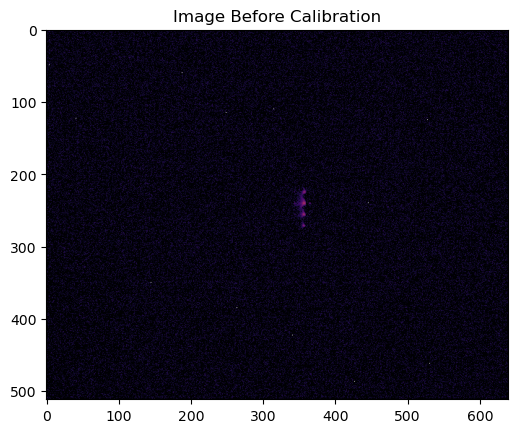

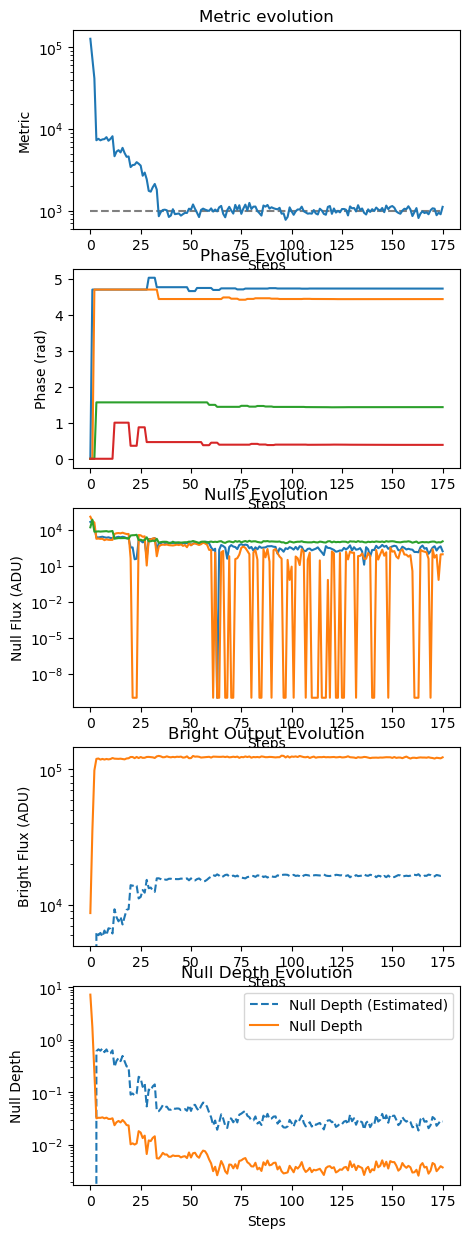

/tmp/ipykernel_1526869/4027350386.py:13: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(img_after_calib), cmap='inferno', vmin=0, vmax=np.percentile(img_after_calib, 99))


Text(0.5, 1.0, 'Image After Calibration')

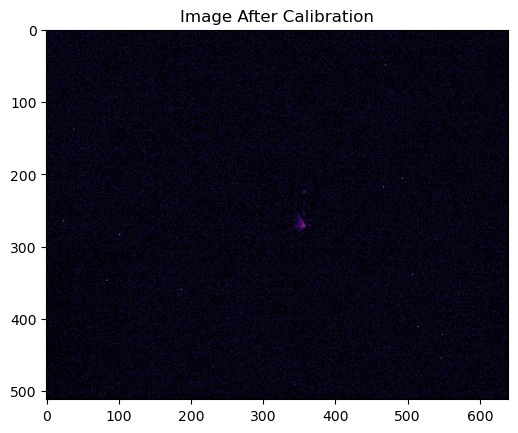

In [6]:
bright_output=0
phobos.FilterWheel().move(2)

img_before_calib = phobos.Cred3().get_image()
img_before_calib[img_before_calib < 0] = 1e-10  # Avoid log of zero
plt.imshow(np.log(img_before_calib), cmap='inferno', vmin=0, vmax=np.percentile(img_before_calib, 99))
plt.title('Image Before Calibration')

calibration_res = phobos.Arch6().null_calibration_gen(bright_output=bright_output, use_dm=False, plot=True, total_flux=total_flux, figsize=(5, 15))

img_after_calib = phobos.Cred3().get_image()
img_after_calib[img_after_calib < 0] = 1e-10  # Avoid log of zero
plt.imshow(np.log(img_after_calib), cmap='inferno', vmin=0, vmax=np.percentile(img_after_calib, 99))
plt.title('Image After Calibration')

In [ ]:
phases = calibration_res["phases"]
history = {"depth": calibration_res["depth_evol"], "shifters": calibration_res["phases_evol"]}
fig_null_calibration = calibration_res.get("figure", None)

In [ ]:
phobos.Arch6().set_phases(phases)
phobos.Cred3().get_outputs(flux_mode='sum')

In [ ]:
calibrated_phasors = phobos.Arch6().predict_phasors(injected_phases=phases)

In [ ]:
import numpy as np
phobos.Arch6().set_phases(phases)

N = 1000

outs = np.zeros((N, 4), dtype=complex)
kernel = np.zeros((N,), dtype=complex)
for i in range(N):
    outs[i] = phobos.Cred3().get_outputs(flux_mode='sum')
    kernel[i] = outs[i,0] - outs[i,3]

# Histograms
import matplotlib.pyplot as plt
distribution_fig, axs = plt.subplots(1, 5, figsize=(12, 5), tight_layout=True)
axs[0].hist(outs[:,0], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Dark 1')
axs[1].hist(outs[:,1], bins=30, color='orange', alpha=0.7)
axs[1].set_title('Null')
axs[2].hist(outs[:,2], bins=30, color='green', alpha=0.7)
axs[2].set_title('Bright')
axs[3].hist(outs[:,3], bins=30, color='red', alpha=0.7)
axs[3].set_title('Dark 2')
axs[4].hist(kernel, bins=30, color='purple', alpha=0.7)
axs[4].set_title('Kernel')
for ax in axs:
    ax.set_xlabel('Integrated flux (ADU)')
    ax.set_ylabel('Occurrences')
plt.show()

print("Median of null depth:")
bright = np.median(np.abs(outs[:,2]))
null = np.median(np.abs(outs[:,1]))
dark_1 = np.median(np.abs(outs[:,0]))
dark_2 = np.median(np.abs(outs[:,3]))
kernel_med = np.median(np.abs(kernel))
print(f"   Null: {null/bright:.2e}")
print(f"   Dark 1: {dark_1/bright:.2e}")
print(f"   Dark 2: {dark_2/bright:.2e}")
print(f"   Kernel: {kernel_med/bright:.2e}")

---
# Save results

In [ ]:
# Turn off
import phobos
phobos.XPOW().turn_off()
phobos.DM().flat()  # Reset injection segments to (piston, tip, tilt) = (0, 0, 0)

model_path = phobos.archive.new("Model Caracterization")
model_path

In [ ]:
# --- MMI characterization ---

# data
np.save(model_path / "A_model", phobos.Arch6().A_model)
np.save(model_path / "Cin_model", phobos.Arch6().C_model)
np.save(model_path / "Eoff_model", phobos.Arch6().Eoff_model)
np.save(model_path / "Eon_model", phobos.Arch6().Eon_model)

# figures
for i, fig in enumerate(solved_matrix.get('figures', [])):
    fig.savefig(model_path / f"Model Fitting with {i+1} inputs.png", dpi=200, bbox_inches="tight")

solved_phasors['figure'].savefig(model_path / "raw_phasors.png", dpi=200, bbox_inches="tight")
calibrated_phasors['figure'].savefig(model_path / "calibrated_phasors.png", dpi=200, bbox_inches="tight")

In [ ]:
# --- Null Calibration ---

null_path = phobos.archive.new("Null Calibration")
print(null_path)

dark1_output = (bright_output + 1) % 4
dark2_output = (bright_output + 2) % 4
null_output = (bright_output + 3) % 4

# data
np.save(null_path / "Null_dsitrib", outs[null_output])
np.save(null_path / "Dark1_dsitrib", outs[dark1_output])
np.save(null_path / "Dark2_dsitrib", outs[dark2_output])
np.save(null_path / "Bright_dsitrib", outs[bright_output])
np.save(null_path / "Kernel_dsitrib", kernel)
np.save(null_path / "Phases_evolution", history['shifters'])
np.save(null_path / "Metric_evolution", history['depth'])

# figures
fig_null_calibration.savefig(null_path / "null_calibration.png", dpi=200, bbox_inches="tight")
distribution_fig.savefig(null_path / "distributions.png", dpi=200, bbox_inches="tight")